In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

!pip install -q transformers datasets sentencepiece scikit-learn

import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, DataCollatorWithPadding, TrainingArguments
from datasets import Dataset

/kaggle/input/datasets/nabilatabassummumu/new-dataset/new_dataset.csv
/kaggle/input/datasets/nabilatabassummumu/old-dataset/old_dataset.csv


### Removing all previously saved model

In [85]:
import shutil

shutil.rmtree("/kaggle/working", ignore_errors=True)

print("All files in /kaggle/working deleted!")

All files in /kaggle/working deleted!


### Reading our new dataset

In [12]:
df = pd.read_csv("https://raw.githubusercontent.com/AzmalSirat/human-vs-ai-classifier/main/new_dataset.csv")

print(df["source"].value_counts())

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
source
gpt                    3681
claud                  3173
Samakal                1458
pdf                    1203
Prothom Alo            1141
Bangladesh Pratidin     943
Ittefaq                 819
Daily Star Bangla       463
Kalbela                 248
Dhaka Post              149
Jugantor                 11
Name: count, dtype: int64


### Stratified split of training and test data

In [7]:
from sklearn.model_selection import train_test_split
import pandas as pd

# ===============================
# Step 1: Balance dataset (50% AI, 50% Human)
# ===============================
df_ai = df[df["class"] == 0]
df_human = df[df["class"] == 1]

min_size = min(len(df_ai), len(df_human))

df_ai_sampled = df_ai.sample(n=min_size, random_state=42)
df_human_sampled = df_human.sample(n=min_size, random_state=42)

df_balanced = pd.concat([df_ai_sampled, df_human_sampled]).reset_index(drop=True)

# ===============================
# Step 2: Create nested stratification column
# (label already balanced, now stratify by source+category)
# ===============================
df_balanced["stratify_col"] = (
    df_balanced["source"].astype(str) + "_" +
    df_balanced["category"].astype(str)
)

# ===============================
# Step 3: Remove rare combinations
# ===============================
combo_counts = df_balanced["stratify_col"].value_counts()
valid_combos = combo_counts[combo_counts > 1].index

df_balanced = df_balanced[df_balanced["stratify_col"].isin(valid_combos)]

# ===============================
# Step 4: Stratified split
# ===============================
train_df, test_df = train_test_split(
    df_balanced,
    test_size=0.2,
    random_state=42,
    stratify=df_balanced["stratify_col"]
)

# ===============================
# Step 5: Cleanup
# ===============================
train_df = train_df.drop(columns=["stratify_col"])
test_df = test_df.drop(columns=["stratify_col"])

# Keep required columns
train_df = train_df[["data", "class"]]
test_df = test_df[["data", "class"]]

train_df = train_df.rename(columns={"data": "text", "class": "label"})
test_df = test_df.rename(columns={"data": "text", "class": "label"})

# ===============================
# Step 6: Check distributions
# ===============================
print("Train label distribution:\n", train_df["label"].value_counts(normalize=True))
print("Test label distribution:\n", test_df["label"].value_counts(normalize=True))

print("\nTrain category distribution:\n", train_df["text"].shape)
print("Test category distribution:\n", test_df["text"].shape)

Train label distribution:
 label
0    0.500049
1    0.499951
Name: proportion, dtype: float64
Test label distribution:
 label
1    0.5
0    0.5
Name: proportion, dtype: float64

Train category distribution:
 (10295,)
Test category distribution:
 (2574,)


### Creating model using new dataset

In [8]:
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))
model_name = "csebuetnlp/banglabert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding="max_length",
        truncation=True,
        max_length=70
    )

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)
train_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = logits.argmax(axis=1)

    accuracy = accuracy_score(labels, preds)
    precision = precision_score(labels, preds)
    recall = recall_score(labels, preds)
    f1 = f1_score(labels, preds)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
)

trainer.train()

config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/10295 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

TrainOutput(global_step=1932, training_loss=0.24569248215258738, metrics={'train_runtime': 495.1938, 'train_samples_per_second': 62.37, 'train_steps_per_second': 3.902, 'total_flos': 1111001847921000.0, 'train_loss': 0.24569248215258738, 'epoch': 3.0})

In [9]:
trainer.save_model("./saved_model")
tokenizer.save_pretrained("./saved_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./saved_model/tokenizer_config.json', './saved_model/tokenizer.json')

### Confusion matrix

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Confusion Matrix:
 [[1221   66]
 [  28 1259]]


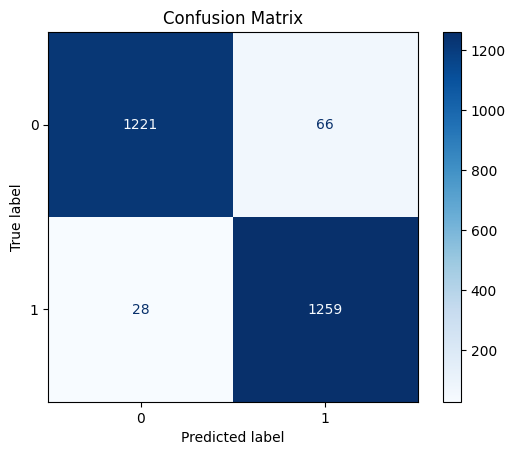

In [92]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ===============================
# Get predictions
# ===============================
predictions = trainer.predict(test_dataset)

logits = predictions.predictions
y_true = predictions.label_ids

# Convert logits → predicted labels
y_pred = np.argmax(logits, axis=1)

# ===============================
# Confusion Matrix
# ===============================
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)

# ===============================
# Plot
# ===============================
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

### Token count for our dataset

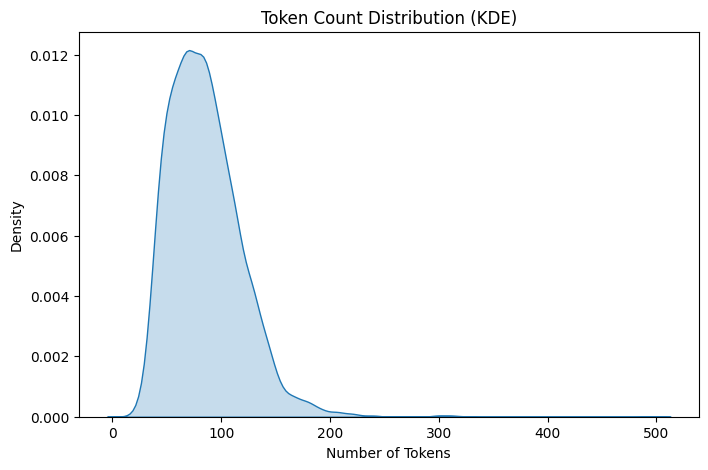

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute token lengths
token_lengths = [len(tokenizer.encode(text, truncation=False)) for text in train_df["text"]]

# Plot KDE
plt.figure(figsize=(8,5))
sns.kdeplot(token_lengths, fill=True)

plt.title("Token Count Distribution (KDE)")
plt.xlabel("Number of Tokens")
plt.ylabel("Density")

plt.show()

In [7]:
import numpy as np

# Convert to array
token_lengths_array = np.array(token_lengths)

# Compute statistics
avg_length = np.mean(token_lengths_array)
std_length = np.std(token_lengths_array)

print(f"Average token length: {avg_length:.2f}")
print(f"Standard deviation: {std_length:.2f}")

Average token length: 85.05
Standard deviation: 33.85


### Test on old dataset using that model

In [17]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from datasets import Dataset
from transformers import Trainer
model_path = "./saved_model"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)
df_new = pd.read_csv("https://raw.githubusercontent.com/AzmalSirat/human-vs-ai-classifier/main/old_dataset.csv")
# Create human samples
df_human = pd.DataFrame({
    "text": df_new["Context(Human)"],
    "label": 1
})
# Create AI samples
df_ai = pd.DataFrame({
    "text": df_new["Context(ChatGpt 1st paraphrase)"],
    "label": 0
})
# Combine
df_new_final = pd.concat([df_human, df_ai], ignore_index=True)
# Remove NaN (important)
df_new_final = df_new_final.dropna()
test_dataset = Dataset.from_pandas(df_new_final.reset_index(drop=True))
def tokenize_function(example):
    return tokenizer(
        example["text"],
        truncation=True,
        padding=False
    )
test_dataset = test_dataset.map(tokenize_function, batched=True)
test_dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
trainer = Trainer(
    model=model,
    # tokenizer=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    compute_metrics=compute_metrics,
)
results = trainer.evaluate(test_dataset)
print(results)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Map:   0%|          | 0/6642 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 2.0016510486602783, 'eval_accuracy': 0.7461607949412827, 'eval_precision': 0.7418687167356594, 'eval_recall': 0.7552679108970499, 'eval_f1': 0.7485083532219571, 'eval_runtime': 35.6973, 'eval_samples_per_second': 186.064, 'eval_steps_per_second': 11.654}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Confusion Matrix:
 [[2444  876]
 [ 849 2473]]


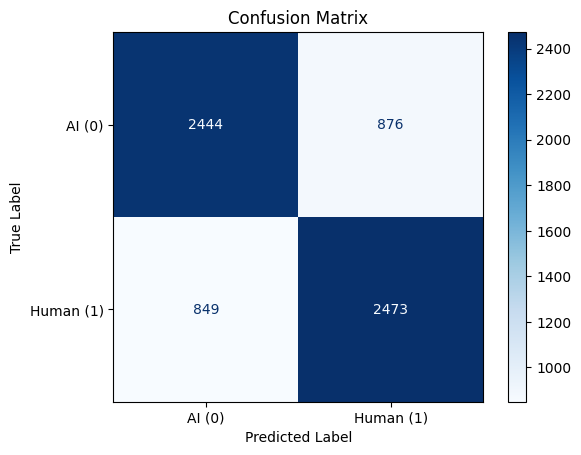

In [95]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# ===============================
# Get predictions
# ===============================
predictions = trainer.predict(test_dataset)

logits = predictions.predictions
y_true = predictions.label_ids

# Convert logits → predicted labels
y_pred = np.argmax(logits, axis=1)

# ===============================
# Confusion Matrix
# ===============================
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)

# ===============================
# Plot
# ===============================
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["AI (0)", "Human (1)"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Using Banglabert for mixed dataset

### Train model using 4400 data from each of two dataset

In [96]:
# ===============================
# Install
# ===============================
!pip install -q transformers datasets sentencepiece scikit-learn

# ===============================
# Imports
# ===============================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

# ===============================
# LOAD DATASET 1 (cleaned)
# ===============================
df1 = pd.read_csv("https://raw.githubusercontent.com/AzmalSirat/human-vs-ai-classifier/main/new_dataset.csv")

# ===============================
# Step 1: Balance FULL dataset (50/50 first)
# ===============================
df1_ai = df1[df1["class"] == 0]
df1_human = df1[df1["class"] == 1]

min_size = min(len(df1_ai), len(df1_human))

df1_ai = df1_ai.sample(n=min_size, random_state=42)
df1_human = df1_human.sample(n=min_size, random_state=42)

df1_balanced_full = pd.concat([df1_ai, df1_human]).reset_index(drop=True)

# ===============================
# Step 2: Stratify column
# ===============================
df1_balanced_full["stratify_col"] = (
    df1_balanced_full["source"].astype(str) + "_" +
    df1_balanced_full["category"].astype(str)
)

# Remove rare combos
counts = df1_balanced_full["stratify_col"].value_counts()
valid = counts[counts > 1].index
df1_balanced_full = df1_balanced_full[df1_balanced_full["stratify_col"].isin(valid)]

# ===============================
# Step 3: Train/Test Split (CORRECT)
# ===============================
train1, test1 = train_test_split(
    df1_balanced_full,
    test_size=0.2,
    stratify=df1_balanced_full["stratify_col"],
    random_state=42
)

# ===============================
# Step 4: NOW sample 2500 per class from TRAIN ONLY
# ===============================
# Count available samples
ai_count = len(train1[train1["class"] == 0])
human_count = len(train1[train1["class"] == 1])

# Take minimum
sample_size = min(ai_count, human_count, 2500)

train1_ai = train1[train1["class"] == 0].sample(n=sample_size, random_state=42)
train1_human = train1[train1["class"] == 1].sample(n=sample_size, random_state=42)

train1 = pd.concat([train1_ai, train1_human]).reset_index(drop=True)

print("Final train size:", len(train1_human))

# train1_ai = train1[train1["class"] == 0].sample(n=2500, random_state=42)
# train1_human = train1[train1["class"] == 1].sample(n=2500, random_state=42)

# train1 = pd.concat([train1_ai, train1_human]).reset_index(drop=True)

# ===============================
# Cleanup
# ===============================
train1 = train1[["data", "class"]].rename(columns={"data": "text", "class": "label"})
test1 = test1[["data", "class"]].rename(columns={"data": "text", "class": "label"})

# ===============================
# LOAD DATASET 2 (old dataset)
# ===============================
df2 = pd.read_csv("https://raw.githubusercontent.com/AzmalSirat/human-vs-ai-classifier/main/old_dataset.csv")

human_df = df2[["Category", "Context(Human)"]].copy()
human_df.columns = ["Category", "text"]
human_df["label"] = 1

ai_df = df2[["Category", "Context(ChatGpt 1st paraphrase)"]].copy()
ai_df.columns = ["Category", "text"]
ai_df["label"] = 0

df2_combined = pd.concat([human_df, ai_df], ignore_index=True)
df2_combined = df2_combined.dropna()

# Balance 2500 each
df2_ai = df2_combined[df2_combined["label"] == 0].sample(n=2200, random_state=42)
df2_human = df2_combined[df2_combined["label"] == 1].sample(n=2200, random_state=42)

df2_balanced = pd.concat([df2_ai, df2_human]).reset_index(drop=True)

train2, test2 = train_test_split(
    df2_balanced,
    test_size=0.2,
    stratify=df2_balanced["Category"],
    random_state=42
)

train2 = train2[["text", "label"]]
test2 = test2[["text", "label"]]

# ===============================
# COMBINE TRAIN DATA
# ===============================
train_combined = pd.concat([train1, train2]).reset_index(drop=True)

# ===============================
# TOKENIZATION
# ===============================
MODEL_NAME = "csebuetnlp/banglabert"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, padding=True, max_length=128)

train_dataset = Dataset.from_pandas(train_combined)
train_dataset = train_dataset.map(tokenize, batched=True)

# ===============================
# MODEL
# ===============================
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

# ===============================
# TRAINING
# ===============================
training_args = TrainingArguments(
    output_dir="/kaggle/working/combined_model",
    num_train_epochs=3,
    per_device_train_batch_size=8,
    logging_dir="./logs",
    save_strategy="epoch"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    data_collator=DataCollatorWithPadding(tokenizer)
)

trainer.train()

# ===============================
# SAVE MODEL
# ===============================
trainer.save_model("/kaggle/working/final_combined_model")
tokenizer.save_pretrained("/kaggle/working/final_combined_model")

print("✅ Model saved!")

Final train size: 2500


Map:   0%|          | 0/8520 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoi

Step,Training Loss
500,0.595513
1000,0.297015
1500,0.152764


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Model saved!


### Test for new dataset

In [97]:
import numpy as np
from sklearn.metrics import classification_report

test_dataset1 = Dataset.from_pandas(test1.reset_index(drop=True))
test_dataset1 = test_dataset1.map(tokenize, batched=True)

pred1 = trainer.predict(test_dataset1)

y_true1 = pred1.label_ids
y_pred1 = np.argmax(pred1.predictions, axis=1)

print("=== DATASET 1 RESULTS ===")
print(classification_report(y_true1, y_pred1))

Map:   0%|          | 0/2574 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


=== DATASET 1 RESULTS ===
              precision    recall  f1-score   support

           0       0.98      0.94      0.96      1287
           1       0.94      0.98      0.96      1287

    accuracy                           0.96      2574
   macro avg       0.96      0.96      0.96      2574
weighted avg       0.96      0.96      0.96      2574



Confusion Matrix:
 [[1206   81]
 [  22 1265]]


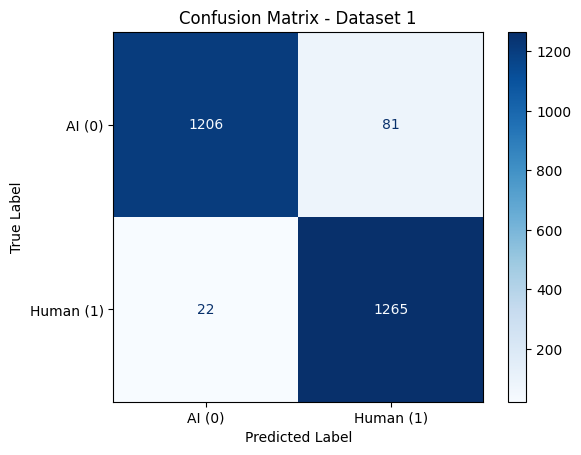

In [98]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ===============================
# Confusion Matrix
# ===============================
cm = confusion_matrix(y_true1, y_pred1)

print("Confusion Matrix:\n", cm)

# ===============================
# Plot
# ===============================
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["AI (0)", "Human (1)"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Dataset 1")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### Test for old dataset

In [99]:
test_dataset2 = Dataset.from_pandas(test2.reset_index(drop=True))
test_dataset2 = test_dataset2.map(tokenize, batched=True)

pred2 = trainer.predict(test_dataset2)

y_true2 = pred2.label_ids
y_pred2 = np.argmax(pred2.predictions, axis=1)

print("=== DATASET 2 RESULTS ===")
print(classification_report(y_true2, y_pred2))

Map:   0%|          | 0/880 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


=== DATASET 2 RESULTS ===
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       425
           1       0.92      0.93      0.93       455

    accuracy                           0.92       880
   macro avg       0.92      0.92      0.92       880
weighted avg       0.92      0.92      0.92       880



Confusion Matrix:
 [[388  37]
 [ 31 424]]


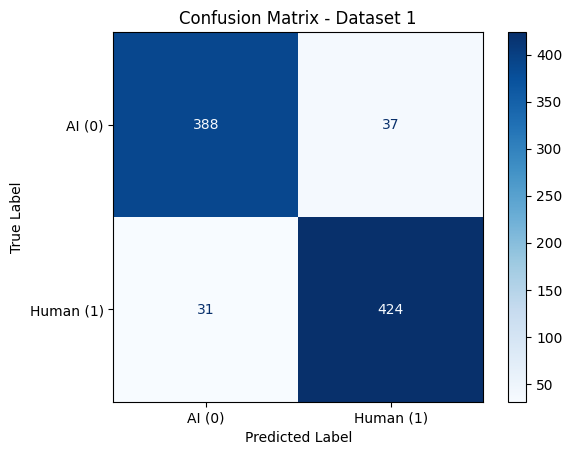

In [100]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ===============================
# Confusion Matrix
# ===============================
cm = confusion_matrix(y_true2, y_pred2)

print("Confusion Matrix:\n", cm)

# ===============================
# Plot
# ===============================
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["AI (0)", "Human (1)"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Dataset 1")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

## Using BanglaBert for older dataset

### train on old model

In [101]:
!pip install -q transformers datasets sentencepiece scikit-learn

import pandas as pd
import numpy as np
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

df = pd.read_csv("https://raw.githubusercontent.com/AzmalSirat/human-vs-ai-classifier/main/old_dataset.csv")
print(df["Category"].value_counts())
human_df = df[["Category", "Context(Human)"]].copy()
human_df.columns = ["Category", "text"]
human_df["label"] = 1

ai_df = df[["Category", "Context(ChatGpt 1st paraphrase)"]].copy()
ai_df.columns = ["Category", "text"]
ai_df["label"] = 0

combined_df = pd.concat([human_df, ai_df], ignore_index=True)
print(combined_df["label"].value_counts())
# checking for NaN value
combined_df["Category"].isna().sum()
combined_df = combined_df.dropna(subset=["Category"])
train_df, test_df = train_test_split(
    combined_df,
    test_size=0.2,
    stratify=combined_df["Category"],
    random_state=42
)
train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df.reset_index(drop=True))
MODEL_NAME = "csebuetnlp/banglabert"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(  # huggingface automatically use Cross-Entropy Loss
    MODEL_NAME,
    num_labels=2
)
train_df["text"].isna().sum()
def tokenize(batch):
    texts = [str(t) for t in batch["text"]]
    return tokenizer(
        texts,
        truncation=True,
        max_length=256
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    acc = accuracy_score(labels, predictions)
    precision = precision_score(labels, predictions)
    recall = recall_score(labels, predictions)
    f1 = f1_score(labels, predictions)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    logging_dir="./logs",
    report_to="none",
    load_best_model_at_end=True
)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)
trainer.train()

Category
Carrier education    400
Social media         200
ফিচার                195
শিল্প ও সাহিত্য      187
বিশেষ সংবাদ          185
স্বাস্থ্য            182
জীবন শৈলী            171
ডট নেট               166
রাজনীতি              160
শিক্ষা               151
পদ্মা সেতু           143
ভ্রমণ                139
ধর্ম                 137
পাঁচমিশালি           132
বাংলাদেশ             122
সর্বশেষ              121
খেলা                  93
অপরাধ                 66
মুক্তচিন্তা           63
আন্তর্জাতিক           42
অর্থনীতি              25
সাক্ষাৎকার            20
জাতীয়                13
চট্টগ্রাম              6
বিনোদন                 5
physical Edu           1
 স্বাস্থ্য             1
Name: count, dtype: int64
label
1    3322
0    3322
Name: count, dtype: int64


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

ElectraForSequenceClassification LOAD REPORT from: csebuetnlp/banglabert
Key                                               | Status     | 
--------------------------------------------------+------------+-
discriminator_predictions.dense.bias              | UNEXPECTED | 
discriminator_predictions.dense_prediction.weight | UNEXPECTED | 
discriminator_predictions.dense.weight            | UNEXPECTED | 
discriminator_predictions.dense_prediction.bias   | UNEXPECTED | 
electra.embeddings.position_ids                   | UNEXPECTED | 
classifier.out_proj.weight                        | MISSING    | 
classifier.dense.weight                           | MISSING    | 
classifier.out_proj.bias                          | MISSING    | 
classifier.dense.bias                             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoi

Map:   0%|          | 0/5001 [00:00<?, ? examples/s]

Map:   0%|          | 0/1251 [00:00<?, ? examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['electra.embeddings.LayerNorm.weight', 'electra.embeddings.LayerNorm.bias', 'electra.encoder.layer.0.attention.output.LayerNorm.weight', 'electra.encoder.layer.0.attention.output.LayerNorm.bias', 'electra.encoder.layer.0.output.LayerNorm.weight', 'electra.encoder.layer.0.output.LayerNorm.bias', 'electra.encoder.layer.1.attention.output.LayerNorm.weight', 'electra.encoder.layer.1.attention.output.LayerNorm.bias', 'electra.encoder.layer.1.output.LayerNorm.weight', 'electra.encoder.layer.1.output.LayerNorm.bias', 'electra.encoder.layer.2.attention.output.LayerNorm.weight', 'electra.encoder.layer.2.attention.output.LayerNorm.bias', 'electra.encoder.layer.2.output.LayerNorm.weight', 'electra.encoder.layer.2.output.LayerNorm.bias', 'electra.encoder.layer.3.attention.output.LayerNorm.weight', 'electra.encoder.layer.3.attention.output.LayerNorm.bias', 'electra.encoder.layer.3.output.LayerNorm.weight', 'electra.encoder.layer.3.output.Laye

TrainOutput(global_step=939, training_loss=0.4346911396843176, metrics={'train_runtime': 308.8451, 'train_samples_per_second': 48.578, 'train_steps_per_second': 3.04, 'total_flos': 1020658144841880.0, 'train_loss': 0.4346911396843176, 'epoch': 3.0})

In [102]:
# Save model + tokenizer
trainer.save_model("./saved_model_v2")
tokenizer.save_pretrained("./saved_model_v2")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./saved_model_v2/tokenizer_config.json', './saved_model_v2/tokenizer.json')

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Confusion Matrix:
 [[579  46]
 [ 41 585]]


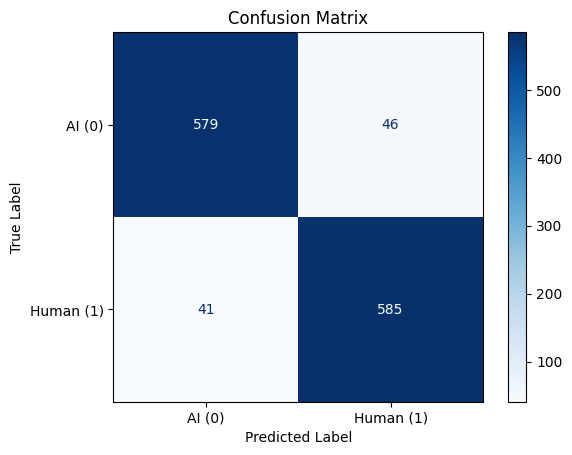

In [103]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# ===============================
# Get predictions
# ===============================
pred = trainer.predict(test_dataset)

y_true = pred.label_ids
y_pred = np.argmax(pred.predictions, axis=1)

# ===============================
# Confusion Matrix
# ===============================
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)

# ===============================
# Plot
# ===============================
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["AI (0)", "Human (1)"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

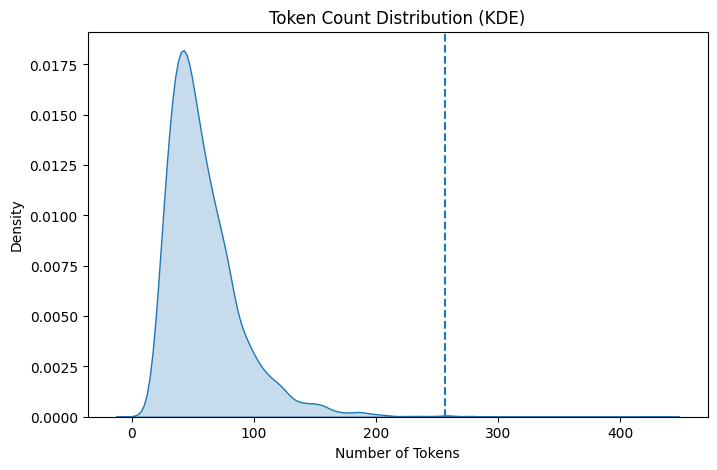

In [104]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute token lengths
token_lengths = [
    len(tokenizer.encode(str(text), truncation=False))
    for text in train_df["text"]
]

# KDE plot
plt.figure(figsize=(8,5))
sns.kdeplot(token_lengths, fill=True)

plt.title("Token Count Distribution (KDE)")
plt.xlabel("Number of Tokens")
plt.ylabel("Density")

# Show max_length reference
plt.axvline(x=256, linestyle='--')

plt.show()

### Test on our dataset

In [105]:

# ================================
# Imports
# ================================
import pandas as pd
import numpy as np
import torch

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding
)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ================================
# Load Model
# ================================
model_path = "./saved_model_v2"

tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSequenceClassification.from_pretrained(model_path)

print("Model loaded!")

# ================================
# Load Dataset
# ================================
df_old = pd.read_csv("https://raw.githubusercontent.com/AzmalSirat/human-vs-ai-classifier/main/new_dataset.csv")

df_old = df_old[["data", "class"]]
df_old = df_old.rename(columns={"data": "text", "class": "label"})
df_old = df_old.dropna(subset=["text"])

print("Dataset loaded:", len(df_old))

# ================================
# Convert to HF Dataset
# ================================
test_dataset = Dataset.from_pandas(df_old.reset_index(drop=True))

# ================================
# Tokenization (MUST match training)
# ================================
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=256
    )

test_dataset = test_dataset.map(tokenize, batched=True)

test_dataset.set_format(
    type="torch",
    columns=["input_ids", "attention_mask", "label"]
)

print("Tokenization done!")

# ================================
# Metrics (FIXED)
# ================================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall": recall_score(labels, preds, zero_division=0),
        "f1": f1_score(labels, preds, zero_division=0),
    }

# ================================
# Trainer Setup (FIXED)
# ================================
training_args = TrainingArguments(
    output_dir="./eval_results",
    per_device_eval_batch_size=32,
    report_to="none"
)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

trainer = Trainer(
    model=model,
    args=training_args,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

# ================================
# Debug Run
# ================================
print("Starting evaluation...")

#small_test = test_dataset.select(range(1000))

results = trainer.evaluate(test_dataset)

print("Evaluation finished!")
print(results)

for k, v in results.items():
    print(f"{k}: {v:.4f}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Model loaded!
Dataset loaded: 13289


Map:   0%|          | 0/13289 [00:00<?, ? examples/s]

Tokenization done!
Starting evaluation...


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Evaluation finished!
{'eval_loss': 2.167973518371582, 'eval_accuracy': 0.7073519452178494, 'eval_precision': 0.6355408858603067, 'eval_recall': 0.9275835275835276, 'eval_f1': 0.754280659632274, 'eval_runtime': 71.2228, 'eval_samples_per_second': 186.583, 'eval_steps_per_second': 2.92}
eval_loss: 2.1680
eval_accuracy: 0.7074
eval_precision: 0.6355
eval_recall: 0.9276
eval_f1: 0.7543
eval_runtime: 71.2228
eval_samples_per_second: 186.5830
eval_steps_per_second: 2.9200


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Confusion Matrix:
 [[3431 3423]
 [ 466 5969]]


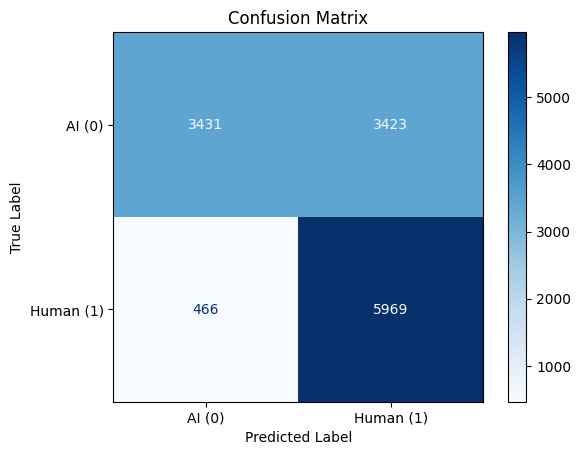

In [106]:
# ===============================
# Confusion Matrix
# ===============================
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Get predictions
predictions = trainer.predict(test_dataset)

logits = predictions.predictions
y_true = predictions.label_ids
y_pred = np.argmax(logits, axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion Matrix:\n", cm)

# Plot
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["AI (0)", "Human (1)"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()